# Model Evaluation & Rest API (FastAPI) - Chicago Rideshare Demand Forecasting

In [16]:
import pandas as pd
import numpy as np
import json
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error)

import sys
import warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path('/Volumes/T7/DS Projects/Chicago Ride Demand Forecasting')
DATA_DIR = Path('/Volumes/T7/DS Projects/Chicago Ride Demand Forecasting/data/processed')
MODELS_DIR = Path('/Volumes/T7/DS Projects/Chicago Ride Demand Forecasting/models')
BEST_DIR = MODELS_DIR / 'best'

for target_dir in sorted(BEST_DIR.iterdir()):
    if target_dir.is_dir():
        for model_dir in target_dir.iterdir():
            if model_dir.is_dir():
                print(f"{target_dir.name} / {model_dir.name}")

T1 / lightgbm
T2 / lightgbm
T3 / xgboost
T4 / lightgbm


In [17]:
def load_h3_data():
    df = pd.read_parquet(DATA_DIR / 'chirde.h3_hourly_comp.parquet')
    print(df.shape)
    print(df.columns)
    return df


def load_citywide_data():
    df = pd.read_parquet(DATA_DIR / 'chirde.citywide_hourly.parquet')
    print(df.shape)
    print(df.columns)
    return df


df_h3 = load_h3_data()
df_citywide = load_citywide_data()

(403248, 95)
Index(['hour_bucket', 'h3_index', 'trip_count', 'avg_fare', 'avg_duration_sec',
       'avg_distance', 'shared_pct', 'hour', 'day_of_week', 'day_of_month',
       'week_of_year', 'is_weekend', 'day_name', 'period_of_day',
       'is_rush_hour', 'date_x', 'is_holiday', 'holiday_name',
       'holiday_proximity', 'is_nye_evening', 'hour_sin', 'hour_cos',
       'dow_sin', 'dow_cos', 'dom_sin', 'dom_cos', 'lag_1h', 'lag_2h',
       'lag_3h', 'lag_24h', 'lag_48h', 'lag_168h', 'demand_change_1h',
       'demand_change_24h', 'roll_3h_mean', 'roll_3h_std', 'roll_6h_mean',
       'roll_6h_std', 'roll_24h_mean', 'roll_24h_std', 'demand_vs_3h_avg',
       'demand_vs_24h_avg', 'cell_avg_fare', 'cell_avg_duration_min',
       'cell_avg_distance', 'cell_tip_rate', 'cell_latitude', 'cell_longitude',
       'demand_percentile', 'demand_category', 'cell_total_trips_norm',
       'neighbor_avg_demand', 'demand_vs_neighbors', 'weekend_hour',
       'holiday_period', 'is_party_time', 'is_wor

In [18]:
for target_dir in sorted(BEST_DIR.iterdir()):
    if not target_dir.is_dir():
        continue
    for model_dir in target_dir.iterdir():
        if not model_dir.is_dir():
            continue
        
        print(f"\n{'─'*60}")
        print(f"{target_dir.name}/{model_dir.name}")
        
        # features.json
        feat_path = model_dir / "features.json"
        if feat_path.exists():
            with open(feat_path) as f:
                raw_feat = json.load(f)
            print(f"\n  features.json → type={type(raw_feat).__name__}")
            if isinstance(raw_feat, dict):
                print(f"  Keys: {list(raw_feat.keys())}")
                for k, v in raw_feat.items():
                    if isinstance(v, list):
                        print(f"'{k}': list of {len(v)} items → {v[:5]}...")
                    else:
                        print(f"'{k}': {v}")
            elif isinstance(raw_feat, list):
                print(f"Length: {len(raw_feat)}")
                print(f"All items: {raw_feat}")
        
        # metadata.json
        meta_path = model_dir / "metadata.json"
        if meta_path.exists():
            with open(meta_path) as f:
                raw_meta = json.load(f)
            print(f"\n  metadata.json → Keys: {list(raw_meta.keys())}")
            for k, v in raw_meta.items():
                if isinstance(v, dict):
                    print(f"'{k}': {v}")
                elif isinstance(v, list):
                    print(f"'{k}': list of {len(v)} → {v[:3]}...")
                else:
                    print(f"'{k}': {v}")
        
        # model.joblib — extract features from the model
        model_path = model_dir / "model.joblib"
        if model_path.exists():
            model = joblib.load(model_path)
            print(f"\nmodel.joblib → {type(model).__name__}")
            
            if hasattr(model, 'feature_names_in_'):
                print(f"feature_names_in_: {len(model.feature_names_in_)} features")
                print(f"First 10: {list(model.feature_names_in_[:10])}")
            
            if hasattr(model, 'feature_name_'):
                fn = model.feature_name_ 
                if isinstance(fn, list):
                    print(f"feature_name_: {len(fn)} features")
                    print(f"First 10: {fn[:10]}")
            
            if hasattr(model, 'n_features_in_'):
                print(f"n_features_in_: {model.n_features_in_}")
            
            if hasattr(model, 'get_booster'):
                try:
                    booster = model.get_booster()
                    bfn = booster.feature_names
                    if bfn:
                        print(f"booster.feature_names: {len(bfn)} features")
                        print(f"First 10: {bfn[:10]}")
                except:
                    pass


for algo in ['lightgbm', 'xgboost']:
    algo_dir = MODELS_DIR / algo
    if not algo_dir.exists():
        continue
    print(f"\n{algo}/")
    for f in sorted(algo_dir.iterdir()):
        print(f"{f.name} ({f.stat().st_size / 1024:.0f} KB)")


────────────────────────────────────────────────────────────
T1/lightgbm

  features.json → type=dict
  Keys: ['target_key', 'target_name', 'target_column', 'task_type', 'model_type', 'val_metrics', 'params', 'feature_names', 'n_features', 'saved_at']
'target_key': T1
'target_name': T1_Citywide_Demand
'target_column': target_1h
'task_type': regression
'model_type': lightgbm
'val_metrics': {'mae': 714.3106, 'rmse': 918.9397, 'mape': 20.7587, 'smape': 17.7728, 'r2': 0.7793, 'median_ae': 595.1175}
'params': {'n_estimators': 1393, 'max_depth': 11, 'learning_rate': 0.036858690486938434, 'num_leaves': 84, 'min_child_samples': 45, 'subsample': 0.5978747058583016, 'colsample_bytree': 0.4761495298835738, 'reg_alpha': 0.0008416292063557243, 'reg_lambda': 0.003290334733288799, 'min_split_gain': 0.013940354279167807}
'feature_names': list of 58 items → ['vs_slot_avg', 'demand_pct_change_1h', 'roll_6h_std', 'roll_168h_min', 'is_snowing']...
'n_features': 58
'saved_at': 2026-03-11T18:31:37.082853



In [19]:
def extract_features_from_model(model_dir: Path, model=None):
    if model is None:
        model = joblib.load(model_dir / "model.joblib")
    
    if hasattr(model, 'feature_name_'):
        names = model.feature_name_ 
        if isinstance(names, list) and len(names) > 0:
            return names, "model.feature_name_"
    
    if hasattr(model, 'feature_names_in_'):
        names = list(model.feature_names_in_)
        if len(names) > 0:
            return names, "model.feature_names_in_"
    
    if hasattr(model, 'get_booster'):
        try:
            names = model.get_booster().feature_names
            if names and len(names) > 0:
                return names, "booster.feature_names"
        except:
            pass
    
    feat_path = model_dir / "features.json"
    if feat_path.exists():
        with open(feat_path) as f:
            raw = json.load(f)
        
        if isinstance(raw, list):
            all_columns = set(df_h3.columns) | set(df_citywide.columns)
            clean = [f for f in raw if f in all_columns]
            if clean:
                return clean, f"features.json (cleaned {len(raw)}→{len(clean)})"
            return raw, "features.json (uncleaned)"
        
        elif isinstance(raw, dict):
            for key in ['features', 'feature_names', 'feature_list', 'columns']:
                if key in raw and isinstance(raw[key], list):
                    return raw[key], f"features.json['{key}']"
    
    target_name = model_dir.parent.name
    for algo_dir_name in ['lightgbm', 'xgboost']:
        algo_dir = MODELS_DIR / algo_dir_name
        if not algo_dir.exists():
            continue
        for csv_file in algo_dir.glob(f"{target_name}_*_feature_importance.csv"):
            fi_df = pd.read_csv(csv_file)
            if 'feature' in fi_df.columns:
                return fi_df['feature'].tolist(), f"feature_importance: {csv_file.name}"
    
    return [], "NO SOURCE FOUND"


print("Feature extraction results:")
print("=" * 60)
for target_dir in sorted(BEST_DIR.iterdir()):
    if not target_dir.is_dir():
        continue
    for model_dir in target_dir.iterdir():
        if not model_dir.is_dir():
            continue
        features, source = extract_features_from_model(model_dir)
        
        h3_match = len(set(features) & set(df_h3.columns))
        city_match = len(set(features) & set(df_citywide.columns))
        
        print(f"\n{target_dir.name}/{model_dir.name}:")
        print(f"Source: {source}")
        print(f"Count: {len(features)}")
        print(f"H3 match: {h3_match}/{len(features)}")
        print(f"Citywide match: {city_match}/{len(features)}")
        print(f"First 10: {features[:10]}")

Feature extraction results:

T1/lightgbm:
Source: model.feature_name_
Count: 58
H3 match: 46/58
Citywide match: 58/58
First 10: ['vs_slot_avg', 'demand_pct_change_1h', 'roll_6h_std', 'roll_168h_min', 'is_snowing', 'avg_tip', 'demand_change_1h', 'slot_avg_leakfree', 'demand_vs_3h_avg', 'hour_sin']

T2/lightgbm:
Source: model.feature_name_
Count: 55
H3 match: 55/55
Citywide match: 43/55
First 10: ['vs_slot_avg', 'cell_avg_fare', 'roll_6h_std', 'is_snowing', 'cta_lines_at_cell', 'demand_change_1h', 'cell_latitude', 'demand_vs_3h_avg', 'hour_sin', 'dow_sin']

T3/xgboost:
Source: model.feature_names_in_
Count: 55
H3 match: 55/55
Citywide match: 43/55
First 10: [np.str_('vs_slot_avg'), np.str_('cell_avg_fare'), np.str_('roll_6h_std'), np.str_('is_snowing'), np.str_('cta_lines_at_cell'), np.str_('demand_change_1h'), np.str_('cell_latitude'), np.str_('demand_vs_3h_avg'), np.str_('hour_sin'), np.str_('dow_sin')]

T4/lightgbm:
Source: model.feature_name_
Count: 58
H3 match: 46/58
Citywide match:

In [20]:
def load_best_models():
    best_models = {}
    
    for target_dir in sorted(BEST_DIR.iterdir()):
        if not target_dir.is_dir():
            continue
        target_name = target_dir.name
        
        for model_dir in target_dir.iterdir():
            if not model_dir.is_dir():
                continue
            
            model_type = model_dir.name
            
            # Load model
            model = joblib.load(model_dir / "model.joblib")
            
            # Load metadata
            with open(model_dir / "metadata.json") as f:
                metadata = json.load(f)
            
            features, source = extract_features_from_model(model_dir, model)
            
            h3_missing = set(features) - set(df_h3.columns)
            city_missing = set(features) - set(df_citywide.columns)
            
            if len(h3_missing) == 0:
                dataset_type = "h3"
                missing = h3_missing
            elif len(city_missing) == 0:
                dataset_type = "citywide"
                missing = city_missing
            elif len(h3_missing) <= len(city_missing):
                dataset_type = "h3"
                missing = h3_missing
            else:
                dataset_type = "citywide"
                missing = city_missing
            
            if missing:
                print(f"{target_name}: Removing {len(missing)} unmatchable features: {missing}")
                features = [f for f in features if f not in missing]
            
            best_models[target_name] = {
                "model": model,
                "features": features,
                "metadata": metadata,
                "model_type": model_type,
                "dataset_type": dataset_type,
                "feature_source": source,
                "path": str(model_dir)
            }
            
            print(f"{'=' * 55}")
            print(f"{target_name} / {model_type}")
            print(f"Feature source: {source}")
            print(f"Dataset: {dataset_type}")
            print(f"Features: {len(features)}")
            print(f"Missing: {len(missing)} → {'None' if len(missing) == 0 else missing}")
            print(f"Test MAE: {metadata.get('metrics', {}).get('test_mae', 'N/A')}")
            print()
    
    return best_models

best_models = load_best_models()
print(f"\nLoaded {len(best_models)} models: {list(best_models.keys())}")

T1 / lightgbm
Feature source: model.feature_name_
Dataset: citywide
Features: 58
Missing: 0 → None
Test MAE: N/A

T2 / lightgbm
Feature source: model.feature_name_
Dataset: h3
Features: 55
Missing: 0 → None
Test MAE: N/A

T3 / xgboost
Feature source: model.feature_names_in_
Dataset: h3
Features: 55
Missing: 0 → None
Test MAE: N/A

T4 / lightgbm
Feature source: model.feature_name_
Dataset: citywide
Features: 58
Missing: 0 → None
Test MAE: N/A


Loaded 4 models: ['T1', 'T2', 'T3', 'T4']


In [21]:
def create_splits(df, col = 'hour_bucket', test_days = 7):
    # Last N days = test set
    split_date = df[col].max() - pd.Timedelta(days=test_days)

    train = df[df[col] <= split_date].copy()
    test = df[df[col] > split_date].copy()

    print(f"Train: {train.shape}, Test: {test.shape} (Split on {split_date.date()})")
    return train, test


train_h3, test_h3 = create_splits(df_h3)
train_citywide, test_citywide = create_splits(df_citywide)

Train: (312192, 95), Test: (91056, 95) (Split on 2024-12-24)
Train: (576, 95), Test: (168, 95) (Split on 2024-12-24)


In [22]:
def inverse_transform_predictions(y_pred, target_type):
    """Convert predictions back to original scale."""
    if target_type in ('T1', 'T4'):
        # predict ride_count
        return np.maximum(y_pred, 0)
    elif target_type == 'T2':
        # predict log1p(ride_count)
        return np.maximum(np.expm1(y_pred), 0)
    elif target_type == 'T3':
        # predict sqrt(ride_count)
        return np.maximum(y_pred, 0) ** 2
    else:
        raise ValueError(f"Unknown target type: {target_type}")

#### Predictions on original scale

In [23]:
results = {}

for target_name, model_info in best_models.items():
    model = model_info['model']
    features = model_info['features']
    dataset_type = model_info['dataset_type']

    test_data = test_h3 if dataset_type == 'h3' else test_citywide

    print(f'Evaluating {target_name} ({model_info['model_type']}) on {dataset_type} data')

    available = [f for f in features if f in test_data.columns]
    not_available = [f for f in features if f not in test_data.columns]

    if not_available:
        print(f"{len(not_available)} features not in test data: {not_available}")
        n_expected = getattr(model, 'n_features_in_', len(features))
        if len(available) != n_expected:
            continue
        features = available

    X_test = test_data[features]
    y_true = test_data['trip_count'].values
    y_pred_native = model.predict(X_test)
    y_pred_original = inverse_transform_predictions(y_pred_native, target_name)

    mae = mean_absolute_error(y_true, y_pred_original)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred_original))
    r2 = r2_score(y_true, y_pred_original)
    median_ae = np.median(np.abs(y_true - y_pred_original))

    mask_nonzero = y_true > 0
    if mask_nonzero.sum() > 0:
        mape = mean_absolute_percentage_error(y_true[mask_nonzero], y_pred_original[mask_nonzero]) * 100
    else:
        mape = np.nan

    results[target_name] = {
        'model_type': model_info['model_type'],
        'dataset_type': dataset_type,
        'y_true': y_true,
        'y_pred': y_pred_original,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'mape': mape,
        'median_ae': median_ae,
        'test_data': test_data,
        'features': features
    }

    print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.4f}, MAPE: {mape:.2f}%, Median AE: {median_ae:.2f}")


Evaluating T1 (lightgbm) on citywide data
MAE: 991.99, RMSE: 1532.09, R²: 0.7690, MAPE: 24.36%, Median AE: 743.05
Evaluating T2 (lightgbm) on h3 data
MAE: 9.11, RMSE: 31.74, R²: -0.0736, MAPE: 93.55%, Median AE: 1.00
Evaluating T3 (xgboost) on h3 data
MAE: 845.29, RMSE: 8123.40, R²: -70317.9844, MAPE: 1976.36%, Median AE: 1.86
Evaluating T4 (lightgbm) on citywide data
MAE: 5099.10, RMSE: 6013.32, R²: -2.5588, MAPE: 100.00%, Median AE: 4864.00


In [24]:
best_target = min(results.keys(), key=lambda t: results[t]['mae'])
best_res = results[best_target]
print(best_res)

{'model_type': 'lightgbm', 'dataset_type': 'h3', 'y_true': array([ 2,  2,  1, ..., 20, 30, 44], shape=(91056,)), 'y_pred': array([0., 0., 0., ..., 0., 0., 0.], shape=(91056,)), 'mae': 9.112767058268055, 'rmse': np.float64(31.740492325495477), 'r2': -0.07355555870974917, 'mape': 93.549349223566, 'median_ae': np.float64(1.0), 'test_data':                hour_bucket         h3_index  trip_count   avg_fare  \
576    2024-12-25 00:00:00  8826641915fffff           2   8.750000   
577    2024-12-25 01:00:00  8826641915fffff           2  12.500000   
578    2024-12-25 02:00:00  8826641915fffff           1  10.000000   
579    2024-12-25 03:00:00  8826641915fffff           3  13.333333   
580    2024-12-25 04:00:00  8826641915fffff           2  12.500000   
...                    ...              ...         ...        ...   
403243 2024-12-31 19:00:00  88275936d5fffff          19  11.184211   
403244 2024-12-31 20:00:00  88275936d5fffff          18  10.833333   
403245 2024-12-31 21:00:00  882

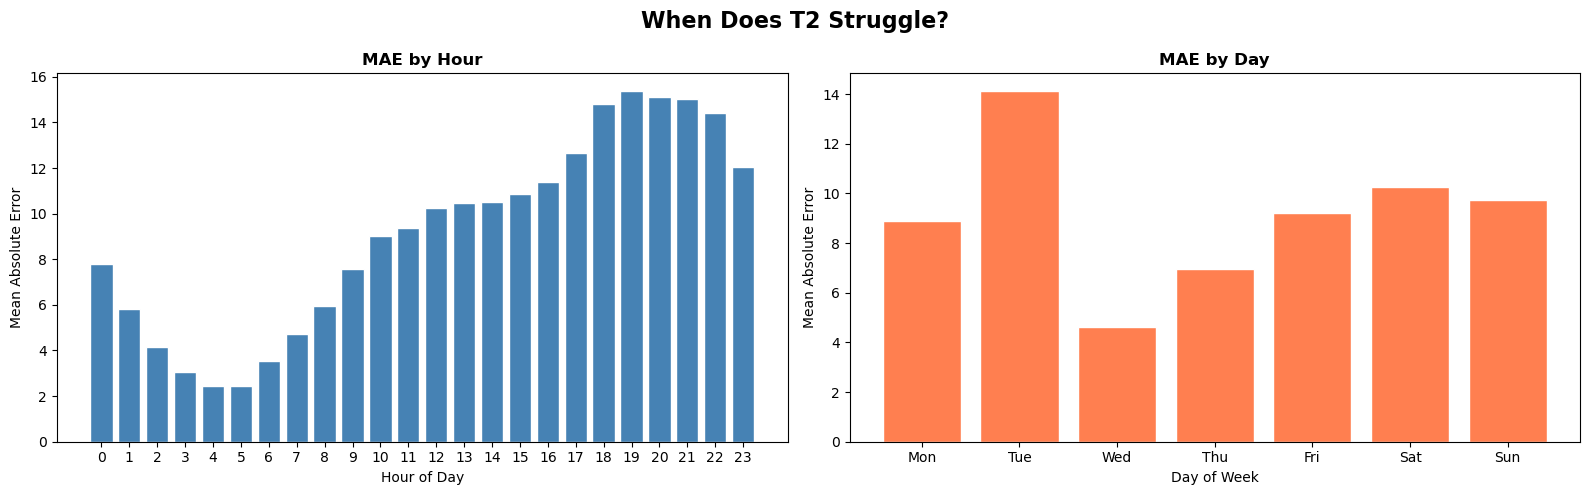

In [25]:
# Error by hour and day of week

test_data = best_res['test_data'].copy()
test_eval = pd.DataFrame({
    'datetime': test_data['hour_bucket'].values,
    'actual': best_res['y_true'],
    'predicted': best_res['y_pred']
})
test_eval['abs_error'] = np.abs(test_eval['actual'] - test_eval['predicted'])
test_eval['hour'] = pd.to_datetime(test_eval['datetime']).dt.hour
test_eval['day_of_week'] = pd.to_datetime(test_eval['datetime']).dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

hourly = test_eval.groupby('hour')['abs_error'].mean()
axes[0].bar(hourly.index, hourly.values, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Mean Absolute Error')
axes[0].set_title('MAE by Hour', fontweight='bold')
axes[0].set_xticks(range(0, 24))

dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily = test_eval.groupby('day_of_week')['abs_error'].mean()
axes[1].bar(dow_names, daily.values, color='coral', edgecolor='white')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Mean Absolute Error')
axes[1].set_title('MAE by Day', fontweight='bold')

plt.suptitle(f"When Does {best_target} Struggle?", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

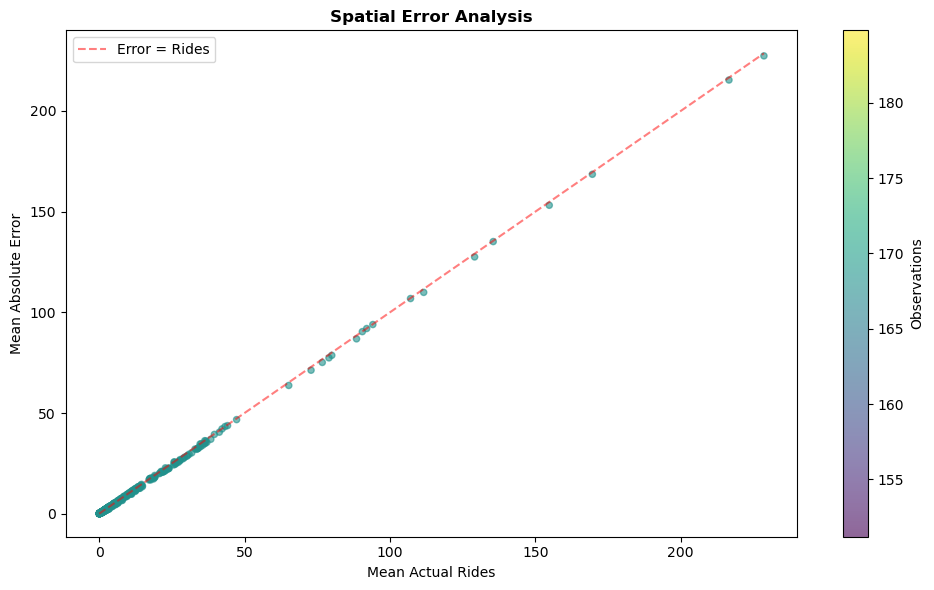

Top 10 hardest hexagons:
       h3_index  mean_rides        mae  count
882664c1e3fffff  228.601190 227.343163    168
882664c1e1fffff  216.577381 215.360265    168
882664c1a9fffff  169.601190 168.547720    168
882664c1edfffff  154.785714 153.159483    168
882664c1adfffff  135.511905 135.133474    168
882664cad7fffff  129.113095 127.505643    168
882664c163fffff  111.601190 109.903364    168
882664c1e7fffff  107.071429 106.846415    168
882664c1abfffff   94.113095  93.939221    168
882664c1e5fffff   91.994048  91.953136    168


In [26]:
# Spatial error (H3 models only)

if best_res['dataset_type'] == 'h3' and 'h3_index' in test_data.columns:
    test_eval['h3_index'] = test_data['h3_index'].values
    
    hex_err = test_eval.groupby('h3_index').agg(
        mae=('abs_error', 'mean'),
        mean_rides=('actual', 'mean'),
        count=('actual', 'size')
    ).reset_index()
    hex_err = hex_err[hex_err['count'] >= 24]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sc = ax.scatter(hex_err['mean_rides'], hex_err['mae'], c=hex_err['count'], cmap='viridis', alpha=0.6, s=20)
    plt.colorbar(sc, label='Observations')
    ax.plot([0, hex_err['mean_rides'].max()], [0, hex_err['mean_rides'].max()], 'r--', alpha=0.5, label='Error = Rides')
    ax.set_xlabel('Mean Actual Rides')
    ax.set_ylabel('Mean Absolute Error')
    ax.set_title('Spatial Error Analysis', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    print("Top 10 hardest hexagons:")
    print(hex_err.nlargest(10, 'mae')[['h3_index', 'mean_rides', 'mae', 'count']].to_string(index=False))
else:
    print("Citywide model — no spatial breakdown")

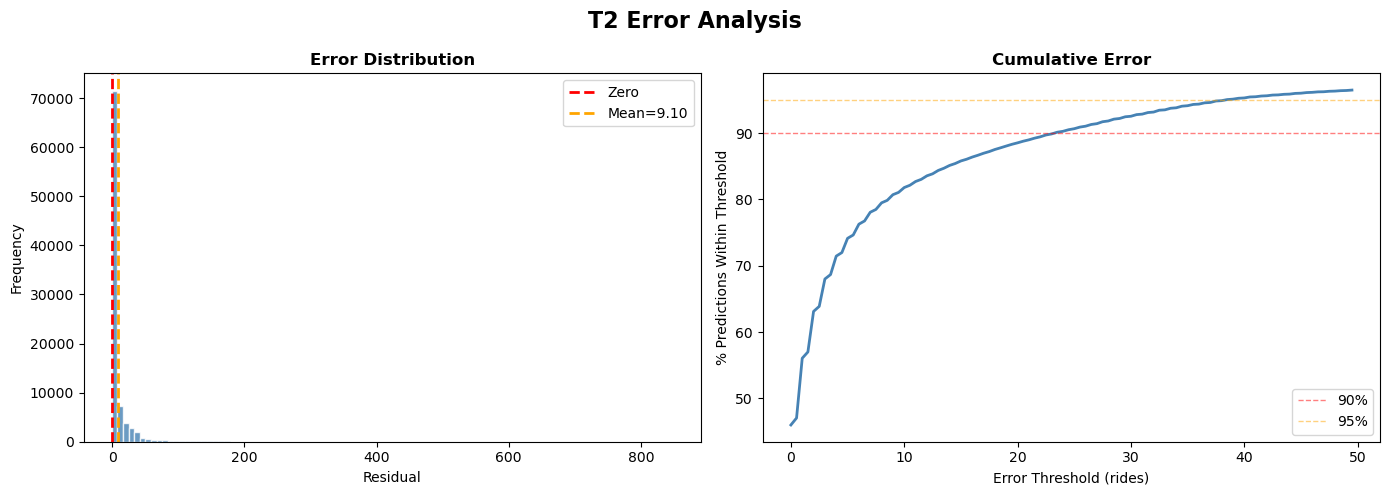

50% of predictions within 1.00 rides
75% of predictions within 6.00 rides
90% of predictions within 23.28 rides
95% of predictions within 38.28 rides
99% of predictions within 135.00 rides


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
residuals = best_res['y_true'] - best_res['y_pred']
abs_errors = np.abs(residuals)

axes[0].hist(residuals, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', lw=2, ls='--', label='Zero')
axes[0].axvline(residuals.mean(), color='orange', lw=2, ls='--', label=f'Mean={residuals.mean():.2f}')
axes[0].set_xlabel('Residual')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Error Distribution', fontweight='bold')
axes[0].legend()

thresholds = np.arange(0, min(50, abs_errors.max()), 0.5)
pcts = [(abs_errors <= t).mean() * 100 for t in thresholds]
axes[1].plot(thresholds, pcts, color='steelblue', lw=2)
axes[1].axhline(90, color='red', lw=1, ls='--', alpha=0.5, label='90%')
axes[1].axhline(95, color='orange', lw=1, ls='--', alpha=0.5, label='95%')
axes[1].set_xlabel('Error Threshold (rides)')
axes[1].set_ylabel('% Predictions Within Threshold')
axes[1].set_title('Cumulative Error', fontweight='bold')
axes[1].legend()

plt.suptitle(f"{best_target} Error Analysis", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

for p in [50, 75, 90, 95, 99]:
    print(f"{p}% of predictions within {np.percentile(abs_errors, p):.2f} rides")

In [28]:
all_results = []

for algo in ['lightgbm', 'xgboost']:
    algo_dir = MODELS_DIR / algo
    if not algo_dir.exists():
        continue
    
    for model_file in sorted(algo_dir.glob("*.joblib")):
        stem = model_file.stem
        parts = stem.split('_')
        target = parts[0]
        variant = parts[-1]
        
        model = joblib.load(model_file)
        
        feat_names = None
        if hasattr(model, 'feature_name_'):
            try:
                feat_names = model.feature_name_()
            except:
                pass
        if feat_names is None and hasattr(model, 'feature_names_in_'):
            feat_names = list(model.feature_names_in_)
        if feat_names is None and hasattr(model, 'get_booster'):
            try:
                feat_names = model.get_booster().feature_names
            except:
                pass
        
        if feat_names is None:
            fi_file = algo_dir / f"{stem}_feature_importance.csv"
            if fi_file.exists():
                feat_names = pd.read_csv(fi_file)['feature'].tolist()
        
        if feat_names is None:
            print(f"Can't get features for {stem}, skipping")
            continue
        
        h3_miss = set(feat_names) - set(df_h3.columns)
        city_miss = set(feat_names) - set(df_citywide.columns)
        
        if len(h3_miss) <= len(city_miss):
            test_data = test_h3
            ds = "h3"
            feat_names = [f for f in feat_names if f in test_h3.columns]
        else:
            test_data = test_citywide
            ds = "city"
            feat_names = [f for f in feat_names if f in test_citywide.columns]
        
        n_expected = getattr(model, 'n_features_in_', len(feat_names))
        if len(feat_names) != n_expected:
            continue
        
        X = test_data[feat_names]
        y = test_data['trip_count'].values
        
        y_pred = inverse_transform_predictions(model.predict(X), target)
        
        mask = y > 0
        all_results.append({
            'target': target, 'algorithm': algo, 'variant': variant,
            'model_id': stem, 'dataset': ds,
            'MAE': mean_absolute_error(y, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y, y_pred)),
            'R²': r2_score(y, y_pred),
            'MAPE_%': mean_absolute_percentage_error(y[mask], y_pred[mask]) * 100 if mask.sum() > 0 else np.nan,
            'n_features': len(feat_names)
        })

comp_df = pd.DataFrame(all_results).sort_values('MAE')
print("MODEL COMPARISON")
print("-" * 100)
print(comp_df.to_string(index=False, float_format='{:.4f}'.format))

MODEL COMPARISON
----------------------------------------------------------------------------------------------------
target algorithm variant       model_id dataset       MAE      RMSE          R²    MAPE_%  n_features
    T2  lightgbm default T2_lgb_default      h3    9.1128   31.7405     -0.0736   93.5493          55
    T2  lightgbm   tuned   T2_lgb_tuned      h3    9.1128   31.7405     -0.0736   93.5493          55
    T2   xgboost default T2_xgb_default      h3    9.1893   31.7214     -0.0723   90.0746          55
    T2   xgboost   tuned   T2_xgb_tuned      h3    9.1894   31.7214     -0.0723   90.0763          55
    T3   xgboost   tuned   T3_xgb_tuned      h3  845.2949 8123.3976 -70317.9844 1976.3618          55
    T3  lightgbm   tuned   T3_lgb_tuned      h3  866.3520 8347.1642 -74245.3526 2006.8194          55
    T3  lightgbm default T3_lgb_default      h3  897.8694 8373.6131 -74716.6129 2083.3522          55
    T3   xgboost default T3_xgb_default      h3  899.3646 8784.089

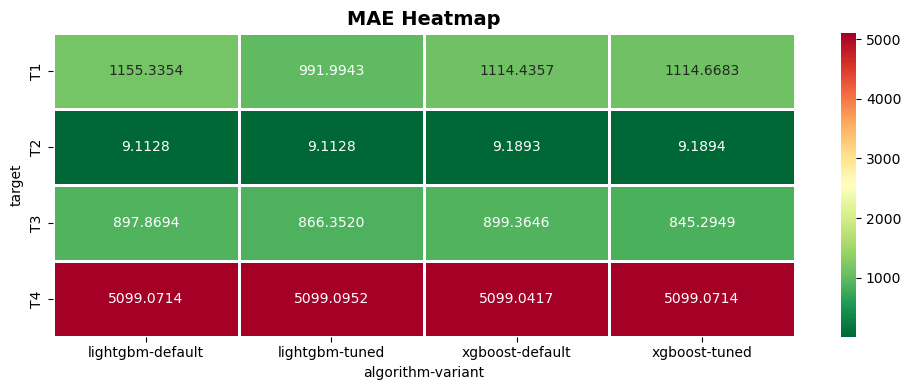

In [29]:
if len(comp_df) > 0:
    pivot = comp_df.pivot_table(values='MAE', index='target', columns=['algorithm', 'variant'], aggfunc='first')
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn_r', ax=ax, linewidths=1)
    ax.set_title('MAE Heatmap', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()